# Transformers and Attention mechanism (using Py torch)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class selfAttention(nn.Module):
    
    def __init__(self,n_embd):
        super().__init__()
        self.Wq = nn.Linear(n_embd , n_embd)
        self.Wk = nn.Linear(n_embd, n_embd)
        self.Wv = nn.Linear(n_embd, n_embd)
        
    def forward(self, x):
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        
        scores = Q @ K.transpose(-2, -1) # (-2,-1) is the standard for the 2D transpose of the matrix
        weights = F.softmax(scores / (K.shape[-1] ** 0.5), dim=-1)
        out = weights @ V  
        return out         
        

In [3]:
class TransformerBlock(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.attn = selfAttention(n_embd)
        self.ff = nn.Sequential(
            nn.Linear(n_embd , 4*n_embd),
            nn.ReLU(),
            nn.Linear(4*n_embd, n_embd)
        )
        
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
       
    def forward(self, x):
        
        x = x +  self.attn(self.ln1(x))
        x = x +  self.ff(self.ln2(x))
        return x

    

- Sequential means used for the applying the stack of the activation function for feeding forward



- LayerNorm means the nomralising the large values like [100, 200, 300] -> [0.23, 0.45, 0.53] and they also have their own factors like 
    - scaling = gamma
    - shifting = beta

    by normalising there is the fault each vector/token mean = 0 and variance = 1 so the gamma and beta is intruduced

In [4]:
class TinyGPT(nn.Module):
    def __init__(self,vocab_size,block_size,n_embd):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.block = TransformerBlock(n_embd)
        self.lm_head = nn.Linear(n_embd , vocab_size)
        
    def forward(self, idx):
        B, T = idx.shape
        tok_emb = self.token_embedding(idx)
        pos = torch.arange(T)
        pos_emb = self.position_embedding(pos)
        x = tok_emb + pos_emb
        x = self.block(x)
        logits = self.lm_head(x)
        return logits 
        

- Above the nn.Embedding is used for the vectorising the words which is encoded in the soti 
   - for ex : stoi["kannada"] = 3 then for converting this to the vectors of (num_embeddings, embedding_dim)

In [5]:
model = TinyGPT(
    vocab_size=100,
    block_size=10,
    n_embd=32
)

x = torch.randint(
    0,
    100,
    (4,10)
)

logits = model(x)
print(logits.shape)

torch.Size([4, 10, 100])


### Testing Part for the model including Optimisation

In [6]:
sentences = [
    # "i love machine learning",
    # "i love deep learning",
    "i love everyone",
    "i love india",
    "i love karnataka",
    "i love kannada",
    "i love nitk",
    "i love artificial intelligence",
    "deep learning is fun",
    "machine learning is powerful",
    "the sky is blue",
    "the grass is green",
    "transformers are powerful",
    "artificial intelligence is amazing",
    "python is easy to learn",
    "i like neural networks",
    "neural networks learn patterns",
    "attention is all you need",
]

In [7]:
words = []

for sentence in sentences:
    words.extend(sentence.split())

words = sorted(list(set(words)))
stoi = {word:i for i, word in enumerate(words)}
itos = {i:word for word, i in stoi.items()}
vocab_size = len(stoi)

print(vocab_size)
print(stoi)

35
{'all': 0, 'amazing': 1, 'are': 2, 'artificial': 3, 'attention': 4, 'blue': 5, 'deep': 6, 'easy': 7, 'everyone': 8, 'fun': 9, 'grass': 10, 'green': 11, 'i': 12, 'india': 13, 'intelligence': 14, 'is': 15, 'kannada': 16, 'karnataka': 17, 'learn': 18, 'learning': 19, 'like': 20, 'love': 21, 'machine': 22, 'need': 23, 'networks': 24, 'neural': 25, 'nitk': 26, 'patterns': 27, 'powerful': 28, 'python': 29, 'sky': 30, 'the': 31, 'to': 32, 'transformers': 33, 'you': 34}


In [8]:
X = []
Y = []

for sentence in sentences:
    tokens = sentence.split()
    for i in range(1, len(tokens)):
        context = tokens[:i]
        target = tokens[i]
        X.append(context)
        Y.append(stoi[target])

In [9]:
block_size = 5

In [10]:
X_num = []

for context in X:
    ids = [stoi[w] for w in context]
    ids = [0] * (block_size - len(ids)) + ids
    X_num.append(ids[-block_size:])

In [11]:
import torch

X = torch.tensor(X_num)
Y = torch.tensor(Y)
print(X.shape)
print(Y.shape)

torch.Size([44, 5])
torch.Size([44])


In [12]:
logits = model(X)
print(logits.shape)

torch.Size([44, 5, 100])


In [13]:
loss = F.cross_entropy(
    logits[:, -1, :],
    Y
)

print(loss)

tensor(5.0044, grad_fn=<NllLossBackward0>)


In [14]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
stepi = []
lossi = []

for i in range(1000):
    
    logits = model(X)
    loss = F.cross_entropy(logits[:, -1 , :],Y)    
    stepi.append(i)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    lossi.append(loss.item())
    
    if i % 100 == 0:
        print(loss.item())

5.004444599151611
0.5013922452926636
0.3805294930934906
0.3753312826156616
0.37401673197746277
0.37345656752586365
0.37316882610321045
0.37300243973731995
0.3728904724121094
0.3726348876953125


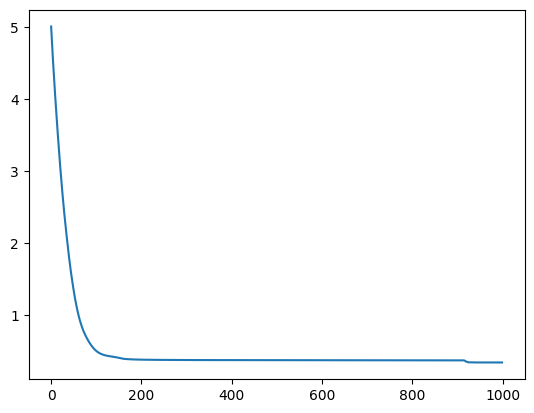

In [15]:
import matplotlib.pyplot as plt
plt.plot(stepi, lossi)

In [ ]:
while True:

    prompt = input("Enter text: ").lower()
    words = prompt.split()
    ids = []
    for w in words:
        if w not in stoi:
            print("Unknown word:", w)
            ids = None
            break
        ids.append(stoi[w])

    if ids is None:
        continue

    ids = [0] * (block_size - len(ids)) + ids
    ids = ids[-block_size:]
    x = torch.tensor([ids])
    with torch.no_grad():
        logits = model(x)
        pred = logits[:, -1, :].argmax(dim=1)
    next_word = itos[pred.item()]

    print("Prediction:", next_word)